Code for analyzing low-level winds and sea level pressure from CM2.5-FLOR Preindustrial simulations forced with CTRL and modified topographic boundary conditions and comparing model output to MERRA-2 reanalysis.

Relevant for manuscript Figure 5

In [1]:
import os
import sys
# block warnings from printing
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

import pandas as pd
import xarray as xr
xr.set_options(keep_attrs=True)
import numpy as np
np.seterr(divide='ignore', invalid='ignore')

import cartopy
cartopy.config['data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
cartopy.config['pre_existing_data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.geometry.polygon import LinearRing
np.NaN = np.nan  # regionmask <0.9 compat with NumPy 2.0
import regionmask

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.lines import Line2D
import seaborn as sns

# settings
%config InlineBackend.figure_format = 'retina'

# add path to custom functions
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path+"/py_functions")
from data_funcs import *
from stats_funcs import *
from domain_funcs import *

dpath0 = '/discover/nobackup/projects/giss/baldwin_nip/dmkumar' # top level data directory

# DATA PROCESSING

In [2]:
### +++ SET DATA PATHS +++ ###

keys=['obs','flor']
obs_prods=['merra2']
flor_runs=['ctrl','hitopo','hicam']

# --- store filepaths --- #
files={ 'obs'  : { prod:{} for prod in obs_prods },
        'flor' : { run: {} for run  in flor_runs } }

for key in ['obs']:
    for prod in obs_prods:
        files[key][prod]['u925'] = f'{dpath0}/obs_data/merra2/merra2.U.1980-2022.monthly.nc' 
        files[key][prod]['v925'] = f'{dpath0}/obs_data/merra2/merra2.V.1980-2022.monthly.nc' 
        files[key][prod]['slp'] = f'{dpath0}/obs_data/merra2/merra2.SLP.1980-2022.monthly.nc' 

for key in ['flor']:
    for run in flor_runs:
        for varn in ['u925','v925','slp']:
            files[key][run][varn] = f'{dpath0}/FLOR/{run}/pi/flor.{run}.{varn}.monthly.nc' 

for key in ['topo']:
    files[key] = {}
    files[key]['etopo'] = f'{dpath0}/topo_files/obs.etopo5.zsurf.nc'
    files[key]['ctrl'] = f'{dpath0}/topo_files/flor.ctrl.zsurf.nc'
    files[key]['hitopo'] = f'{dpath0}/topo_files/flor.hitopo.zsurf.nc'
    files[key]['hicam'] = f'{dpath0}/topo_files/flor.hicam.zsurf.nc'

In [3]:
## +++ LOAD & ORGANIZE DATA +++ ##

dat = { 'obs'  : { prod:{} for prod in obs_prods },
        'flor' : { run: {} for run  in flor_runs } }
topo = {}

# --- sub-setting bounds --- #
latmin, latmax = 10, 55
lonmin, lonmax = 215, 285
plev = 925 # pressure level
yr_min, yr_max = '0101', '0200'

# --- read & subset raw fields --- #
print('Loading data...')

# Reanalysis
for key in ['obs']:
    print(f'{key}')
    for run in obs_prods:
        print(f'->{run}')
        for i, ovarn in enumerate(['U', 'V']):
            varn = ['u925', 'v925'][i]
            ds_full = xr.open_dataset(files[key][run][varn])[ovarn].sel(lev=plev, drop=True)
            ds_full = lonFlip(ds_full)
            dat[key][run][varn] = ds_full.sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
            
        slp_full = xr.open_dataset(files[key][run]['slp'])['SLP'] / 100 # Pa -> hPa
        slp_full = lonFlip(slp_full)
        slp_gm = lat_weighted_mean(slp_full) # global mean
        slp_rm = lat_weighted_mean(slp_full.sel(lat=slice(20,37), lon=slice(240,256))) 
        
        dat[key][run]['slp']  = slp_full.sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
        dat[key][run]['slpa'] = dat[key][run]['slp'] - slp_gm
        dat[key][run]['slpra'] = dat[key][run]['slp'] - slp_rm

# CM2.5-FLOR model output
for key in ['flor']:
    print(f'\n{key}')
    for run in flor_runs:
        print(f'->{run}')
        for varn in ['u925', 'v925']:
            ds_full = xr.open_dataset(files[key][run][varn])[varn].sel(time=slice(yr_min, yr_max))
            ds_full = ds_full.rename({'grid_xt': 'lon', 'grid_yt': 'lat'})
            ds_full['lat'].attrs['units'] = 'degrees_north'
            ds_full['lon'].attrs['units'] = 'degrees_east'
            dat[key][run][varn] = ds_full.sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
            
        slp_full = xr.open_dataset(files[key][run]['slp'])['slp'].sel(time=slice(yr_min, yr_max))
        slp_gm = lat_weighted_mean(slp_full) # global mean
        slp_rm = lat_weighted_mean(slp_full.sel(lat=slice(20,37), lon=slice(240,256))) # regional mean

        dat[key][run]['slp']  = slp_full.sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
        dat[key][run]['slpa'] = dat[key][run]['slp'] - slp_gm
        dat[key][run]['slpra'] = dat[key][run]['slp'] - slp_rm


# --- read & subset topography fields --- #
print('\nLoading topography fields...')
for case,filen in files['topo'].items():
    if case=='etopo':
        ds = xr.open_dataset(files['topo'][case]).ROSE.rename({'ETOPO05_X':'lon', 'ETOPO05_Y':'lat'})
        topo[case] = ds.where(ds>0, np.nan).sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
        del ds
    elif case in ['ctrl', 'hitopo', 'hicam']:
        ds = xr.open_dataset(files['topo'][case]).ZSURF.rename({'GRID_XT':'lon', 'GRID_YT':'lat'})
        topo[case] = ds.sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
        del ds

print('\nDone.')

Loading data...
obs
->merra2

flor
->ctrl
->hitopo
->hicam

Loading topography fields...

Done.


In [4]:
### +++ CALCULATE TIME-MEANS +++ ###

varns = ['u925', 'v925', 'slp', 'slpa', 'slpra']


jas_mean     = { 'obs'  : { prod:{} for prod in obs_prods },
                 'flor' : { run: {} for run  in flor_runs } }
ann_jas_mean = { 'obs'  : { prod:{} for prod in obs_prods },
                 'flor' : { run: {} for run  in flor_runs } }
jas_all_mos  = { 'obs'  : { prod:{} for prod in obs_prods },
                 'flor' : { run: {} for run  in flor_runs } }


print('Calculating weighted JAS means of raw fields...')
run_map = {'obs': obs_prods, 'flor': flor_runs}
for key, runs in run_map.items():
    print(f'->{key}')
    
    for run in runs:
        print(f'--->{run}')
        # create a mask of time coordinate based on a single variable
        jas_mask = dat[key][run]['u925']['time'].dt.month.isin([7,8,9])
        
        for varn in varns:
            jas_mean[key][run][varn]     = jas_seasonal_mean(dat[key][run][varn]).load()
            ann_jas_mean[key][run][varn] = jas_yearly_mean(dat[key][run][varn]).load()
            # just select all jas months, no time-averaging
            jas_all_mos[key][run][varn]  = dat[key][run][varn].sel(time=jas_mask)

print('\nDone.')

Calculating weighted JAS means of raw fields...
->obs
--->merra2
->flor
--->ctrl
--->hitopo
--->hicam

Done.


In [5]:
## +++ COMPARING ALL MODEL RUNS TO OBS. +++ ##

# --- interpolate obs to FLOR grid --- #
print('Re-gridding obs to model grid...\n')

jas_mean_regrid     = {'obs_flor': {}}
ann_jas_mean_regrid = {'obs_flor': {}}

lats=dat['flor']['ctrl']['slp'].lat
lons=dat['flor']['ctrl']['slp'].lon

for varn in varns:
    jas_mean_regrid['obs_flor'][varn] = jas_mean['obs']['merra2'][varn].interp(lat=lats, lon=lons, method='linear')
    ann_jas_mean_regrid['obs_flor'][varn] = ann_jas_mean['obs']['merra2'][varn].interp(lat=lats, lon=lons, method='linear')


# --- Significance testing of field differences --- #
print('Significance testing (model - obs)...')

obs_diff      = {'ctrl': {}, 'hitopo': {}, 'hicam': {}}
obs_diff_mask = {'ctrl': {}, 'hitopo': {}, 'hicam': {}}
obs_ptvals    = {'ctrl': {}, 'hitopo': {}, 'hicam': {}}

for run in obs_diff.keys():
    print(f'->{run}')
    for varn in varns:
        diff_, diff_mask_, ptvals_ = sigtest2n(ann_jas_mean['flor'][run][varn], ann_jas_mean_regrid['obs_flor'][varn], 
                                               jas_mean['flor'][run][varn],     jas_mean_regrid['obs_flor'][varn])
        obs_diff[run][varn] = diff_
        obs_diff_mask[run][varn] = diff_mask_
        obs_ptvals[run][varn] = ptvals_


# --- Mask vectors where both are significant --- #
obs_usig = {'ctrl': {}, 'hitopo': {}, 'hicam': {}}
obs_vsig = {'ctrl': {}, 'hitopo': {}, 'hicam': {}}

for run in flor_runs:
    obs_usig[run], obs_vsig[run] = wind_sig_mask(obs_diff_mask[run]['u925'], obs_diff_mask[run]['v925'])

print('\nDone.')

Re-gridding obs to model grid...

Significance testing (model - obs)...
->ctrl
->hitopo
->hicam

Done.


In [6]:
## +++ TOPO SENSITIVITY (Modified_Topo - CTRL) +++ ##

# --- Significance testing of field differences --- #
model_diff      = {'hitopo':{}, 'hicam':{}}
model_diff_mask = {'hitopo':{}, 'hicam':{}}
model_ptvals    = {'hitopo':{}, 'hicam':{}}

print('Significance testing (modified_topo - ctrl)...')
for run in model_diff.keys():
    print(f'-> {run}')
    for varn in varns:
        diff_, mask_, pvals_ = sigtest(ann_jas_mean['flor'][run][varn], ann_jas_mean['flor']['ctrl'][varn],
                                       jas_mean['flor'][run][varn], jas_mean['flor']['ctrl'][varn])
        model_diff[run][varn]      = diff_
        model_diff_mask[run][varn] = mask_
        model_ptvals[run][varn]    = pvals_


# --- Mask wind components where both are significant --- #
model_usig = {'hitopo': {}, 'hicam': {}}
model_vsig = {'hitopo': {}, 'hicam': {}}

for run in model_usig.keys():
    model_usig[run], model_vsig[run] = wind_sig_mask(model_diff_mask[run]['u925'], model_diff_mask[run]['v925'])

print('\nDone.')

Significance testing (modified_topo - ctrl)...
-> hitopo
-> hicam

Done.


## FIGURES

### Maps of climatological slp or slp anomaly and 925 hPa winds

In [ ]:
# --- settings --- #
text_kw={'color':'k', 'weight':'bold', 'size':20, 'ha':'left', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':26, 'ha':'center', 'va':'center'}
text_kw3={'color':'k', 'weight':'normal', 'size':14, 'ha':'left', 'va':'center'}
titles=np.array(['MERRA2', 'CTRL', r'HI$_{\mathbf{gbl}}$', r'HI$_{\mathbf{mex}}$'])
letters=['A','B','C','D']
tx=-130.5
ty=50.25
# vector specs
skip_nh=2
skip_nl=1
w=0.004
scalef=8
key_length=5
# slp colormap
dcmap=cm.RdYlBu_r
dvmin=1005
dvmax=1025
dlevels=np.linspace(dvmin, dvmax, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(1000,4000,4)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[225,270,15,50]

# --- plot --- #
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(22,5), layout='constrained', subplot_kw={'projection':proj})

fig.text(0.025,-0.02,
         'Jul.-Sept. climatology. Vectors are 925 hPa winds.'
         'Thin black lines are model surface height boundary conditions, intervals of 1 km starting at 1 km.',
         **text_kw3)

i=0
for key, runs in [('obs', obs_prods), ('flor', flor_runs)]:
    for run in runs:
        slp = jas_mean[key][run]['slp']
        u = jas_mean[key][run]['u925']
        v = jas_mean[key][run]['v925']
        if key=='flor':
            topo_ = topo[run]
        else:
            topo_ = topo['etopo']
        cf=ax[i].pcolormesh(slp.lon, slp.lat, slp, cmap=dcmap, norm=dnorm, transform=trans)
        q1=ax[i].quiver(u.lon[::skip_nh], u.lat[::skip_nh], u[::skip_nh,::skip_nh], v[::skip_nh,::skip_nh],
                        color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
        qk=ax[i].quiverkey(q1, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
        ax[i].contour(topo_.lon, topo_.lat, topo_, levels=zlevels, linewidths=0.75, colors='black', transform=trans)
        i+=1

# --- formatting --- #
for i, ax in enumerate(ax.flat): 
    # subplot labels
    ax.text(tx, ty, titles[i], **text_kw)
    ax.text(tx-5, ty+1.5, letters[i], **text_kw2)
    # map properties
    ax.coastlines(color='k', linewidth=1)
    ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=1)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=(i==0); gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

# --- colorbar --- #
cax=fig.add_axes([1.01, 0.15, 0.02, 0.7])
cbar=fig.colorbar(cf, ticks=np.linspace(dvmin,dvmax,5), orientation='vertical', extend='both', cax=cax)
cbar.set_label('SLP [hPa]', labelpad=25, rotation=270, size=18, fontweight='normal', ha='center') 
cbar.ax.tick_params(labelsize=18)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

In [ ]:
# --- settings --- #
text_kw={'color':'k', 'weight':'bold', 'size':20, 'ha':'left', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':26, 'ha':'center', 'va':'center'}
text_kw3={'color':'k', 'weight':'normal', 'size':14, 'ha':'left', 'va':'center'}
titles=np.array(['MERRA2', 'CTRL', r'HI$_{\mathbf{gbl}}$', r'HI$_{\mathbf{mex}}$'])
letters=['A','B','C','D']
tx=-130.5
ty=50.25
# vector specs
skip_nh=2
skip_nl=1
w=0.004
scalef=8
key_length=5
# slpa colormap
dcmap=cm.RdBu_r
dvmin=-10
dvmax=10
dlevels=np.linspace(dvmin, dvmax, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(1000,4000,4)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[225,270,15,50]

# --- plot --- #
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(22,5), layout='constrained', subplot_kw={'projection':proj})

fig.text(0.025,-0.02,
         'Jul.-Sept. climatology. Vectors are 925 hPa winds. '
         'Thin black lines are model surface height boundary conditions, intervals of 1 km starting at 1 km.',
         **text_kw3)

i=0
for key, runs in [('obs', obs_prods), ('flor', flor_runs)]:
    for run in runs:
        slp = jas_mean[key][run]['slpa']
        u = jas_mean[key][run]['u925']
        v = jas_mean[key][run]['v925']
        if key=='flor':
            topo_ = topo[run]
        else:
            topo_ = topo['etopo']
        cf=ax[i].pcolormesh(slp.lon, slp.lat, slp, cmap=dcmap, norm=dnorm, transform=trans)
        q1=ax[i].quiver(u.lon[::skip_nh], u.lat[::skip_nh], u[::skip_nh,::skip_nh], v[::skip_nh,::skip_nh],
                        color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
        qk=ax[i].quiverkey(q1, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
        ax[i].contour(topo_.lon, topo_.lat, topo_, levels=zlevels, linewidths=0.75, colors='black', transform=trans)
        i+=1

# --- formatting --- #
for i, ax in enumerate(ax.flat): 
    # subplot labels
    ax.text(tx, ty, titles[i], **text_kw)
    ax.text(tx-5, ty+1.5, letters[i], **text_kw2)
    # map properties
    ax.coastlines(color='k', linewidth=1)
    ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=1)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=(i==0); gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

# --- colorbar --- #
cax=fig.add_axes([1.01, 0.15, 0.02, 0.7])
cbar=fig.colorbar(cf, ticks=np.linspace(dvmin,dvmax,11), orientation='vertical', extend='both', cax=cax)
cbar.set_label('SLP anomaly\nrelative to global mean [hPa]', labelpad=35, rotation=270, size=16, fontweight='normal', ha='center') 
cbar.ax.tick_params(labelsize=16)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

### Figure 5: CM2.5-FLOR CTRL bias and change in HIgbl and HIcam relative to CTRL for SLP anomaly and 925 hPa winds

#### First, define regions to average Gulf of California Low-Level Jet strength and along-gulf SLP gradient 

In [7]:
## +++ CALCULATE AREA-WEIGHTED MEAN PR BIASES +++ ##
domains = ['slp_dsrt','slp_sgoc', 'gocllj']
coords_map = { d: [] for d in domains}
coords_calc = { d: [] for d in domains}

coords_map['slp_dsrt'] = rotated_box(-114, 33, 4, 3.2, angle_deg=15)
coords_calc['slp_dsrt'] = [ ((lon + 360) % 360, lat) for lon, lat in coords_map['slp_dsrt'] ]

coords_map['slp_sgoc'] = rotated_box(-108, 22.5, 3, 3.5, angle_deg=33)
coords_calc['slp_sgoc'] = [ ((lon + 360) % 360, lat) for lon, lat in coords_map['slp_sgoc'] ]

coords_map['gocllj'] = rotated_box(-113.8, 32, 2.2, 4, angle_deg=5)
coords_calc['gocllj'] = [ ((lon + 360) % 360, lat) for lon, lat in coords_map['gocllj'] ]

regions = regionmask.Regions(
    outlines=[coords_calc['slp_dsrt'], coords_calc['slp_sgoc'], coords_calc['gocllj']],
    names=["slp_dsrt", "slp_sgoc", "gocllj"],
    abbrevs=["slp_dsrt", "slp_sgoc", "gocllj"]
)

In [ ]:
## +++ CHECK REGION BOUNDS AGAINST MERRA-2 CLIMATOLOGY +++ ##
# vector specs
skip_nh=1
w=0.004
scalef=6
key_length=2
# topography contours
zlevels=np.linspace(800,3800,5)
# init fig
proj, trans = ccrs.PlateCarree(), ccrs.PlateCarree()
fig, axs = plt.subplots( 1, 2, figsize=(12,6), subplot_kw={'projection': proj}, constrained_layout=True)
ax1, ax2 = axs

# var info
key='obs'
run='merra2'
slp  = jas_mean[key][run]['slpa']
u925 = jas_mean[key][run]['u925']
v925 = jas_mean[key][run]['v925']

# --- slp anomaly --- #
p1 = slp.plot(ax=ax1, vmin=-4, vmax=4, transform=ccrs.PlateCarree(),
              cmap='RdBu_r', cbar_kwargs={'shrink':0.7, 'extend':'both'})
poly1 = patches.Polygon(coords_map['slp_dsrt'], closed=True, ec='fuchsia', fc='none', lw=2.5, ls='--', transform=trans)
poly2 = patches.Polygon(coords_map['slp_sgoc'], closed=True, ec='fuchsia', fc='none', lw=2.5, ls='--', transform=trans)
ax1.add_patch(poly1)
ax1.add_patch(poly2)
ax1.set_title('SLP anomaly rel. to global mean')

# --- 925 hPa winds --- #
p2 = v925.plot(ax=ax2, vmin=-4, vmax=4, transform=ccrs.PlateCarree(),
               cmap='RdYlBu',cbar_kwargs={'shrink':0.7, 'extend':'both'})
poly3 = patches.Polygon(coords_map['gocllj'],   closed=True, ec='#CA6B02',    fc='none', lw=2.5, ls='--', transform=trans)
ax2.add_patch(poly3)
# vectors
q = ax2.quiver(u925.lon[::skip_nh], u925.lat[::skip_nh], u925[::skip_nh,::skip_nh], v925[::skip_nh,::skip_nh],
               color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
ax2.quiverkey(q, 1.05, .9, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='N', fontproperties={'size':8})
ax2.set_title('925 hPa wind')

for ax in axs:
    # topography
    ax.contour(topo['etopo'].lon, topo['etopo'].lat, topo['etopo'], levels=zlevels, linewidths=0.8, colors='black', transform=trans)
    # map bounds
    ax.coastlines(linewidth=1.25)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
    ax.set_extent([-120, -105, 20, 38])
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.75, linestyle='--')
    gl.top_labels = False; gl.right_labels = False
    gl.xlocator = plt.FixedLocator(range(-180,181,5))
    gl.ylocator = plt.FixedLocator(range(-90,91,5))

plt.savefig(f'../figs/slpa_925wind_merra2_climo.pdf', transparent=False, bbox_inches='tight')
plt.savefig(f'../figs/slpa_925wind_merra2_climo.png', transparent=False, bbox_inches='tight')

In [9]:
## +++ CALCULATE REGIONAL-MEAN VALUES +++ ##
# slpa and v925 regional means (per-year July, August, and September months)
slp_dsrt = {}
slp_sgoc = {}
slp_diff = {}
v_llj    = {}

run_map = {'obs': ['merra2'], 'flor': ['ctrl', 'hitopo', 'hicam']}
for key, run_list in run_map.items():
    for run in run_list:
        slpa_jas_mos = jas_all_mos[key][run]['slpa']
        v_jas_mos    = jas_all_mos[key][run]['v925']
        
        # regions defined two cells above, calculate weighted mean values for each
        slp_regions = regional_weighted_mean(slpa_jas_mos, regions)
        v_regions   = regional_weighted_mean(v_jas_mos, regions)
        
        # Select by region name
        slp_dsrt[run] = slp_regions.sel(region='slp_dsrt')
        slp_sgoc[run] = slp_regions.sel(region='slp_sgoc')
        slp_diff[run] = slp_sgoc[run] - slp_dsrt[run]
        
        v_llj[run]    = v_regions.sel(region='gocllj')

# create dataframes
slp_dsrt_df = pd.concat(
    {model: da.to_series() for model, da in slp_dsrt.items()},
    axis=1
)

slp_sgoc_df = pd.concat(
    {model: da.to_series() for model, da in slp_sgoc.items()},
    axis=1
)

slp_diff_df = pd.concat(
    {model: da.to_series() for model, da in slp_diff.items()},
    axis=1
)

llj_df = pd.concat(
    {model: da.to_series() for model, da in v_llj.items()},
    axis=1
)

#### Then, make plot of fields and distributions

In [ ]:
# --- settings --- #
text_kw={'color':'k', 'weight':'bold', 'size':22, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':24, 'ha':'center', 'va':'center'}
runs = ['MERRA2', 'CTRL', 'HI$_{gbl}$', 'HI$_{mex}$']
map_titles=['CTRL$-$MERRA2', r'HI$_{\mathbf{gbl}}$$-$CTRL', r'HI$_{\mathbf{mex}}$$-$CTRL']
bottom_titles = [ 'Along-Gulf SLP Gradient', 'GoCLLJ Strength', 'SLP Gradient–GoCLLJ\nRelationship']
letters = list("abcdefgh")
tx=-111.5
ty=36.25
# vector specs
skip_nh=1
w=0.0035
scalef=5
key_length=2
# distribution colors
colors = ['black','lightsteelblue','firebrick','peru'] #darkred
# bias colormap
dcmap=cm.coolwarm #RdBu_r
dvmin=-2.5
dvmax=2.5
dlevels=np.linspace(dvmin, dvmax, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(800,3800,7)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[242,255.5,20,36]

# --- plot layout --- #
fig = plt.figure(figsize=(20, 12), constrained_layout=True)
gs = gridspec.GridSpec(nrows=2, ncols=3, height_ratios=[2.2, 1], figure=fig)
# define axes explicitly
ax_map = [
    fig.add_subplot(gs[0, 0], projection=proj),
    fig.add_subplot(gs[0, 1], projection=proj),
    fig.add_subplot(gs[0, 2], projection=proj),
]
ax_kde_slp = fig.add_subplot(gs[1, 0])
ax_kde_llj = fig.add_subplot(gs[1, 1])
ax_scatter = fig.add_subplot(gs[1, 2])

# --- slpa fields --- #
for i,run in enumerate(flor_runs):
    ax = ax_map[i]
    topo_ = topo[run]
    if run=='ctrl':
        slpa = obs_diff_mask[run]['slpa']
        u = obs_usig[run]
        v = obs_vsig[run]
    else:
        slpa = model_diff_mask[run]['slpa']
        u = model_usig[run]
        v = model_vsig[run]
        
    cf=ax.pcolormesh(slpa.lon, slpa.lat, slpa, cmap=dcmap, norm=dnorm, transform=trans) 
    q1=ax.quiver(u.lon[::skip_nh], u.lat[::skip_nh], u[::skip_nh,::skip_nh], v[::skip_nh,::skip_nh],
                 color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
    #ax.contour(topo_.lon, topo_.lat, topo_, levels=zlevels, linewidths=1.5, colors='black', transform=trans)

for i, ax in enumerate(ax_map): 
    # subplot labels
    ax.text(tx, ty, map_titles[i], **text_kw)
    ax.text(-117.5, ty+0.25, letters[i], **text_kw2)
    # boxes around regions averaged
    poly1=patches.Polygon(coords_map['slp_dsrt'], closed=True, ec='fuchsia', fc='none', lw=4, ls='--', transform=ccrs.PlateCarree(), zorder=100); ax.add_patch(poly1)
    poly2=patches.Polygon(coords_map['slp_sgoc'], closed=True, ec='fuchsia', fc='none', lw=4, ls='--', transform=ccrs.PlateCarree(), zorder=100); ax.add_patch(poly2)
    poly3=patches.Polygon(coords_map['gocllj'], closed=True, ec='lemonchiffon', fc='none', lw=4, ls='--', transform=ccrs.PlateCarree(), zorder=100); ax.add_patch(poly3)
    # map properties
    ax.coastlines(color='k', linewidth=2)
    #ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=1.5)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=2)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.left_labels = (i == 0); gl.bottom_labels = True; gl.top_labels = False; gl.right_labels = False
    gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':18}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':18}

# --- SLP KDE --- #
for col, c in zip(slp_diff_df.columns, colors):
    vals = slp_diff_df[col].dropna()
    sns.kdeplot(
        data=vals,
        ax=ax_kde_slp,
        fill=True,
        color=c,
        label=col
    )
    ax_kde_slp.axvline(vals.mean(), color=c, lw=2)
    ax_kde_slp.axvline(vals.median(), color=c, lw=2, ls='--')
ax_kde_slp.set_xlabel('Relative SLP Diff. [hPa]', fontsize=20)
ax_kde_slp.set_ylabel('Density', fontsize=20)
#ax_kde_slp.set_xlim([0, 4.4])
ax_kde_slp.set_title('d', loc='left', **text_kw2)

# --- LLJ KDE --- #
for col, c in zip(llj_df.columns, colors):
    vals = llj_df[col].dropna()
    sns.kdeplot(
        data=vals,
        ax=ax_kde_llj,
        fill=True,
        color=c,
        label=col
    )
    ax_kde_llj.axvline(vals.mean(), color=c, lw=2)
    ax_kde_llj.axvline(vals.median(), color=c, lw=2, ls='--')
ax_kde_llj.set_xlabel('925 hPa $V$-Wind Speed [m/s]', fontsize=20)
ax_kde_llj.set_ylabel('Density', fontsize=20)
ax_kde_llj.set_title('e', loc='left', **text_kw2)

stat_handles = [
    Line2D([0], [0], color='k', lw=2, ls='-',  label='Mean'),
    Line2D([0], [0], color='k', lw=2, ls='--', label='Median'),
]
ax_kde_slp.legend(
    handles=stat_handles,
    loc='upper left',
    frameon=False,
    fontsize=20
)

# --- SLP-LLJ Scatter --- #
for i, run in enumerate(['merra2','ctrl','hitopo','hicam']):
    x = slp_diff[run]
    y = v_llj[run]
    ax_scatter.scatter(
        x,y,
        100,
        ec='k',
        fc=colors[i],
        alpha=0.65,
        label=run
    )
    # linear trend
    m, b = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 100)
    ax_scatter.plot(
        xx,
        m * xx + b,
        color=colors[i],
        lw=3
    )
ax_scatter.set_xlabel('Relative SLP Diff. [hPa]', fontsize=20)
ax_scatter.set_ylabel('925 hPa V-Wind Speed [m/s]', fontsize=20)
ax_scatter.set_title('f', loc='left', **text_kw2)

for ax, title in zip([ax_kde_slp, ax_kde_llj, ax_scatter], bottom_titles):
    ax.text(0.5, 1.01, title, transform=ax.transAxes, **text_kw)
for ax in [ax_kde_slp, ax_kde_llj, ax_scatter]:
    ax.tick_params(which='major', labelsize=20)

legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor=c,
        markeredgecolor='k',
        markersize=15,
        label=run
    )
    for run, c in zip(runs, colors)
]
fig.legend(handles=legend_handles, handletextpad=0.4, fontsize=20, ncol=1, frameon=False, 
           loc='center right', bbox_to_anchor=(1.375, 0.5), bbox_transform=ax_scatter.transAxes)

# --- colorbar --- #
cax=fig.add_axes([1.01, 0.4, 0.02, 0.55])
cbar=fig.colorbar(cf, ticks=np.linspace(dvmin,dvmax,11), orientation='vertical', extend='both', cax=cax)
cbar.set_label('$\Delta$ Relative SLP [hPa]', labelpad=25, rotation=270, size=20, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=20)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

# --- output --- #
plt.savefig(f'../figs/slpa_925wind_merra2-bias_change_flor_pi.pdf', transparent=False, bbox_inches='tight')
plt.savefig(f'../figs/slpa_925wind_merra2-bias_change_flor_pi.png', transparent=False, bbox_inches='tight')

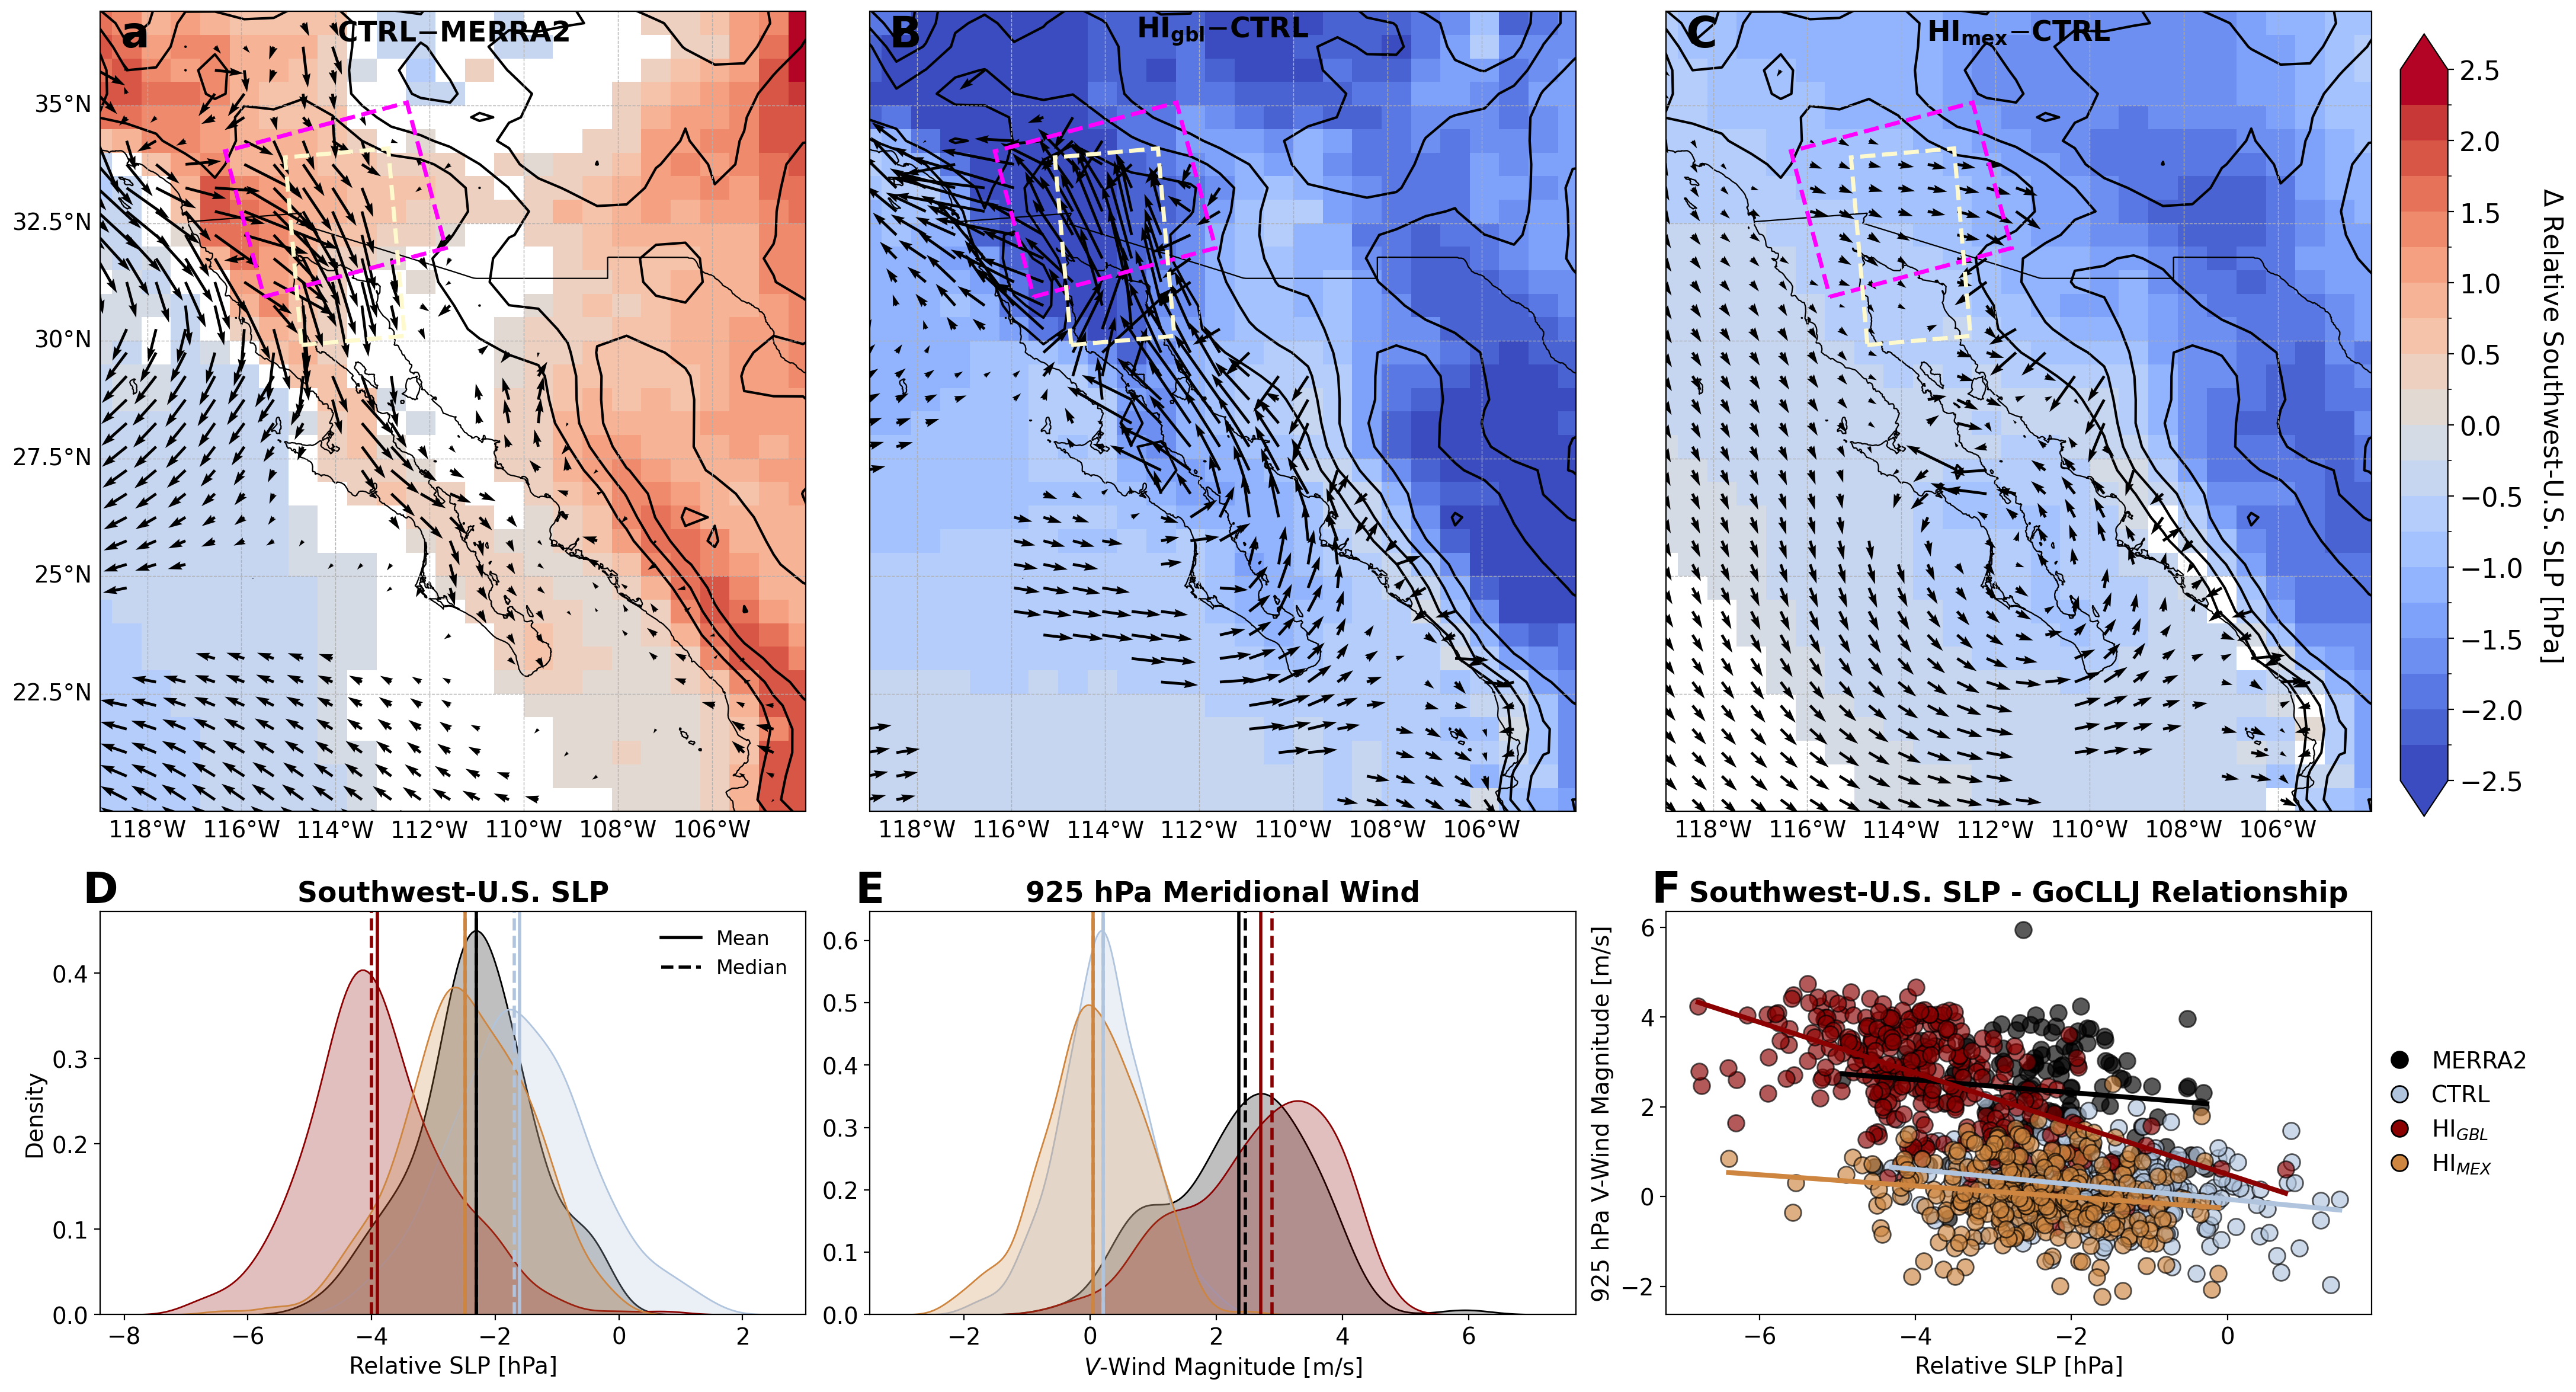

In [27]:
text_kw={'color':'k', 'weight':'bold', 'size':17, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':26, 'ha':'center', 'va':'center'}
runs = ['MERRA2', 'CTRL', 'HI$_{GBL}$', 'HI$_{MEX}$']
map_titles=['CTRL$-$MERRA2', r'HI$_{\mathbf{gbl}}$$-$CTRL', r'HI$_{\mathbf{mex}}$$-$CTRL']
bottom_titles = [ 'Southwest-U.S. SLP', '925 hPa Meridional Wind', 'Southwest-U.S. SLP - GoCLLJ Relationship']
letters=['a','B','C','D','E','F']
tx=-111.5
ty=36.25
# var specs
lat=jas_mean['flor']['ctrl']['slp'].lat
lon=jas_mean['flor']['ctrl']['slp'].lon
# vector specs
skip_nh=1
skip_nl=1
w=0.0035
scalef=5
key_length=1
# distribution colors
colors = ['black','lightsteelblue','darkred','peru']
# bias colormap
dcmap=cm.coolwarm
dvmin=-2.5
dvmax=2.5
dlevels=np.linspace(dvmin, dvmax, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(800,3800,7)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[241,256,20,37]


fig = plt.figure(figsize=(20, 12), constrained_layout=True)
gs = gridspec.GridSpec(nrows=2, ncols=3, height_ratios=[2.2, 1], figure=fig)
# define axes explicitly
ax_map = [
    fig.add_subplot(gs[0, 0], projection=proj),
    fig.add_subplot(gs[0, 1], projection=proj),
    fig.add_subplot(gs[0, 2], projection=proj),
]
ax_kde_slp = fig.add_subplot(gs[1, 0])
ax_kde_llj = fig.add_subplot(gs[1, 1])
ax_scatter = fig.add_subplot(gs[1, 2])


# --- slpa fields --- #
for i,run in enumerate(flor_runs):
    ax = ax_map[i]
    topo_ = topo[run]
    if run=='ctrl':
        slpa = obs_diff_mask[run]['slpa']
        u = obs_usig[run]
        v = obs_vsig[run]
    else:
        slpa = model_diff_mask[run]['slpa']
        u = model_usig[run]
        v = model_vsig[run]
        
    cf=ax.pcolormesh(slpa.lon, slpa.lat, slpa, cmap=dcmap, norm=dnorm, transform=trans) 
    q1=ax.quiver(u.lon[::skip_nh], u.lat[::skip_nh], u[::skip_nh,::skip_nh], v[::skip_nh,::skip_nh],
                 color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
    ax.contour(topo_.lon, topo_.lat, topo_, levels=zlevels, linewidths=1.5, colors='black', transform=trans)

for i, ax in enumerate(ax_map): 
    # subplot labels
    ax.text(tx, ty, map_titles[i], **text_kw)
    ax.text(-118.25, ty+0.25, letters[i], **text_kw2)
    # boxes around regions averaged
    poly1=patches.Polygon(coords_map['slp_dsrt'], closed=True, ec='fuchsia', fc='none', lw=2.5, ls='--', transform=ccrs.PlateCarree(), zorder=100); ax.add_patch(poly1)
    poly3=patches.Polygon(coords_map['gocllj'], closed=True, ec='lemonchiffon', fc='none', lw=2.5, ls='--', transform=ccrs.PlateCarree(), zorder=100); ax.add_patch(poly3)
    # map properties
    ax.coastlines(color='k', linewidth=.8)
    #ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=.75)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=.8)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.left_labels = (i == 0); gl.bottom_labels = True; gl.top_labels = False; gl.right_labels = False
    gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

#=== SLP KDE ===
for col, c in zip(slp_dsrt_df.columns, colors):
    vals = slp_dsrt_df[col].dropna()
    sns.kdeplot(
        data=vals,
        ax=ax_kde_slp,
        fill=True,
        color=c,
        label=col
    )
    ax_kde_slp.axvline(vals.mean(), color=c, lw=2)
    ax_kde_slp.axvline(vals.median(), color=c, lw=2, ls='--')
ax_kde_slp.set_xlabel('Relative SLP [hPa]', fontsize=14)
ax_kde_slp.set_ylabel('Density', fontsize=14)
#ax_kde_slp.set_xlim([0, 4.4])
ax_kde_slp.set_title('D', loc='left', **text_kw2)

#=== LLJ KDE ===
for col, c in zip(llj_df.columns, colors):
    vals = llj_df[col].dropna()
    sns.kdeplot(
        data=vals,
        ax=ax_kde_llj,
        fill=True,
        color=c,
        label=col
    )
    ax_kde_llj.axvline(vals.mean(), color=c, lw=2)
    ax_kde_llj.axvline(vals.median(), color=c, lw=2, ls='--')
ax_kde_llj.set_xlabel('$V$-Wind Magnitude [m/s]', fontsize=14)
ax_kde_llj.set_ylabel('')
ax_kde_llj.set_title('E', loc='left', **text_kw2)

stat_handles = [
    Line2D([0], [0], color='k', lw=2, ls='-',  label='Mean'),
    Line2D([0], [0], color='k', lw=2, ls='--', label='Median'),
]
ax_kde_slp.legend(
    handles=stat_handles,
    loc='upper right',
    frameon=False,
    fontsize=12
)

#=== SLP-LLJ Scatter ===
for i, run in enumerate(['merra2','ctrl','hitopo','hicam']):
    x = slp_dsrt[run]
    y = v_llj[run]
    ax_scatter.scatter(
        x,y,
        100,
        ec='k',
        fc=colors[i],
        alpha=0.65,
        label=run
    )
    # linear trend
    m, b = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 100)
    ax_scatter.plot(
        xx,
        m * xx + b,
        color=colors[i],
        lw=3
    )
ax_scatter.set_xlabel('Relative SLP [hPa]', fontsize=14)
ax_scatter.set_ylabel('925 hPa V-Wind Magnitude [m/s]', fontsize=14)
ax_scatter.set_title('F', loc='left', **text_kw2)

for ax, title in zip([ax_kde_slp, ax_kde_llj, ax_scatter], bottom_titles):
    ax.text(0.5, 1.01, title, transform=ax.transAxes, **text_kw)
for ax in [ax_kde_slp, ax_kde_llj, ax_scatter]:
    ax.tick_params(which='major', labelsize=14)

legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor=c,
        markeredgecolor='k',
        markersize=10,
        label=run
    )
    for run, c in zip(runs, colors)
]
fig.legend(handles=legend_handles, handletextpad=0.4, loc='center right', ncol=1, frameon=False, fontsize=14, bbox_to_anchor=(1.25, 0.5), bbox_transform=ax_scatter.transAxes)

# colorbar
cax=fig.add_axes([1.01, 0.4, 0.02, 0.55])
cbar=fig.colorbar(cf, ticks=np.linspace(dvmin,dvmax,11), orientation='vertical', extend='both', cax=cax)
cbar.set_label('$\Delta$ Relative Southwest-U.S. SLP [hPa]', labelpad=25, rotation=270, size=16, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=16)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')
